# Public Sentiment and Discussion Patterns Surrounding Formula 1 Safety on X

**Course:** COSC2671 Social Media and Network Analytics  
**Assignment:** Assignment 2  
**Topic:** Formula 1 safety discussions on Youtube 

This notebook investigates how users on Youtube discuss Formula 1 safety issues. The analysis combines text preprocessing, exploratory data analysis, sentiment analysis, topic modelling, and network analysis to understand the main themes and patterns in public discussion.

## 1. Introduction (draft 1)

### Discussion
 This study analyses public discussion on Youtube around Formula 1 safety to identify dominant themes, sentiment patterns, and network structures within safety-related conversations.

Possible research questions:

1. What are the most common topics in F1 safety discussions on Youtube?
2. Is public sentiment mostly positive, negative, or neutral?
3. Which hashtags, keywords, or user mentions are most central in the discussion network?
4. How do sentiment and topic patterns connect with network communities?

Social media platforms have become a primary source of discussion, opinion formation, and exchange of information. Users not only express their views through text but also interact with one another, forming complex networks of influence and engagement. 
As a result, analysing online content requires more than just traditional text mining techniques — it demands an integrated approach that considers both what people say and how they are connected.

This study explores discussions surrounding *how does social media discussion influence perceptions of safety in Formula 1 after major accidents* by combining Natural Language Processing (NLP) and network analysis. 
The goal is to move beyond surface-level insights and uncover deeper patterns in sentiment, and interaction structures, by leveraging methods such as sentiment analysis, topic modelling, and transformer-based language models. The textual content of user-generated data can be systematically examined. At the same time, constructing and analysing interaction networks enables the identification of influential entities, community structures, and patterns of information flow.

## 2. Setup and Imports

Install the required libraries first if needed:

In [24]:
!pip install google-api-python-client pandas numpy matplotlib seaborn nltk textblob langdetect scikit-learn networkx python-louvain wordcloud transformers torch sentence-transformers deep_translator

In [25]:
# Core data tools
import os
import re
import json
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# YouTube API
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

# Language detection
from langdetect import detect, LangDetectException

# NLP
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

# Feature extraction and topic modelling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Network analysis
import networkx as nx

# Optional community detection
try:
    import community as community_louvain
    HAS_LOUVAIN = True
except ImportError:
    HAS_LOUVAIN = False

# Optional BERT / sentence embeddings
try:
    from sentence_transformers import SentenceTransformer
    HAS_SENTENCE_TRANSFORMERS = True
except ImportError:
    HAS_SENTENCE_TRANSFORMERS = False

# Download NLTK resources if needed
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/arnavv/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/arnavv/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/arnavv/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/arnavv/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 3. YouTube API

In [26]:
# ── YouTubeProcessing.py ───────────────────────────────────
# Provides the YouTubeProcessing class with a .process() method.
# Centralises tokenisation + stopword filtering (no stemming).
from YouTubeProcessing import YouTubeProcessing

# ── youtubeTextProcessing.py ───────────────────────────────
# Provides processText() which adds Porter stemming on top.
# This function is what youtubeTextProcessing.py uses in its main loop.


print('Helper modules imported.')
print('  YouTubeProcessing.process() — tokenise + filter (no stemming)')
print('  processText()               — tokenise + stem + stopword removal')

Helper modules imported.
  YouTubeProcessing.process() — tokenise + filter (no stemming)
  processText()               — tokenise + stem + stopword removal


## 5. Load Data

Data has already been collected by running `fetchYoutubeAPI.py`, which saved all
videos and their comments to `youtubeDataDump.json`.
This section loads that file and reconstructs the two DataFrames used throughout
the notebook: `video_df` (one row per video) and `comments_df` (one row per comment).

If the JSON is missing, run `python fetchYoutubeAPI.py` once to regenerate it.

**No API quota is consumed here.**

In [27]:
# ── Load from youtubeDataDump.json ──────────────────────────────────────
import json, os, pandas as pd

JSON_PATH = "youtubeDataDump.json"  # adjust path if the file lives elsewhere

if not os.path.exists(JSON_PATH):
    raise FileNotFoundError(
        f"{JSON_PATH} not found.\n"
        "Run  python fetchYoutubeAPI.py  first to generate it."
    )

with open(JSON_PATH, "r", encoding="utf-8") as f:
    dump = json.load(f)

videos_raw = dump["videos"]

# ── Build video_df (drop the nested comments list) ───────────────────────
video_records = [
    {k: v for k, v in vid.items() if k != "comments"}
    for vid in videos_raw
]
video_df = pd.DataFrame(video_records)

# ── Build comments_df (flatten all comments, attach video metadata) ──────
comment_records = []
for vid in videos_raw:
    for c in vid.get("comments", []):
        comment_records.append({
            **c,
            "videoId":    vid["videoId"],
            "videoTitle": vid["title"],
        })

comments_df = pd.DataFrame(comment_records)

print(f"Videos  : {len(video_df)}")
print(f"Comments: {len(comments_df)}")
video_df.head(3)


Videos  : 60
Comments: 14149


,title,videoId,channelTitle,publishedAt,viewCount,likeCount,commentCount,durationSecs,category
0,Grosjean 3D Crash Animation - F1 Bahrain 2020,AAeQHfwtr5s,Crashalong,2020-12-04T04:52:55Z,7051815,63790,2787,280,safety_discussion
1,Drivers’ Radio Reaction to Grosjean's Crash | F1 2020 Bahrain Grand Prix,qDaElY_1_0k,P1 UNFILTERED,2020-11-29T23:31:57Z,9327834,139288,4921,421,safety_discussion
2,The 10 Most Dramatic Crashes of the 2020 F1 Season,ZGd9A2IhQeU,FORMULA 1,2021-01-10T15:00:12Z,7604800,112908,1810,553,safety_discussion


## 8. Data Cleaning

### Data Cleaning and Further Pre-processing

Raw social media data often contains noise and inconsistencies that can negatively affect downstream NLP and network analysis tasks. Therefore, an additional cleaning and preprocessing stage is performed to improve the overall quality, consistency, and reliability of the dataset.

A custom cleaning function, `clean_basic_text()`, is applied to each comment to remove unnecessary textual elements commonly found in online discussions, including:

- URLs and website links  
- User mentions (`@username`)  
- Hashtags  
- Excess whitespace and formatting inconsistencies  

These elements are removed because they typically provide limited semantic value for sentiment analysis or topic modelling and may introduce noise into the feature extraction process.

After the initial text cleaning stage, several additional preprocessing steps are performed:

- Comments are converted to string format to ensure consistency across the dataset.
- Empty comments are removed to avoid invalid or meaningless entries.
- Duplicate comments are removed using the cleaned text field (`text_clean_basic`) to reduce redundancy and prevent repeated messages from biasing the analysis.

The notebook also converts publication timestamps into proper datetime objects for both videos and comments. This enables potential temporal analysis later in the project, such as examining how public sentiment or discussion topics evolve over time.

The cleaned dataset (`comments_clean`) provides a more structured and reliable textual corpus for the later stages of the analysis pipeline, including:
- TF-IDF feature extraction
- Bigram analysis
- Sentiment analysis
- Topic modelling
- BERT-based semantic analysis
- Network construction

This preprocessing stage is important because the quality of text preparation directly influences the performance and interpretability of NLP models and analytical results.

In [28]:
## Data cleaning and further pre-processing
def clean_basic_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)      # remove URLs
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)          # remove mentions
    text = re.sub(r"#[A-Za-z0-9_]+", " ", text)          # remove hashtags symbol and term
    text = re.sub(r"\s+", " ", text).strip()
    return text

comments_clean = comments_df.copy()
comments_clean["text"] = comments_clean["text"].astype(str)
comments_clean["text_clean_basic"] = comments_clean["text"].apply(clean_basic_text)

# Remove empty and duplicate comments
comments_clean = comments_clean[comments_clean["text_clean_basic"].str.len() > 0]
comments_clean = comments_clean.drop_duplicates(subset="text_clean_basic")

# Convert dates to datetime (for video_df and comments_df if applicable)
video_df["publishedAt"] = pd.to_datetime(video_df["publishedAt"])
if "publishedAt" in comments_clean.columns:
    comments_clean["publishedAt"] = pd.to_datetime(comments_clean["publishedAt"])

print(comments_clean.shape)
comments_clean.head()

(14088, 9)


,author,text,originalText,originalLang,publishedAt,likeCount,videoId,videoTitle,text_clean_basic
0,@Crashalong,"Watch the much more realistic looking reconstruction of this accident (https://youtu.be/8xmrNw9VLOk), which featured...","Watch the much more realistic looking reconstruction of this accident (https://youtu.be/8xmrNw9VLOk), which featured...",en,2021-02-21 11:41:42+00:00,275,AAeQHfwtr5s,Grosjean 3D Crash Animation - F1 Bahrain 2020,Watch the much more realistic looking reconstruction of this accident ( which featured also in the Canal+ documentar...
1,@fastmclaren71,Every driver that lost his or her life in a race car saved Romain.,Every driver that lost his or her life in a race car saved Romain.,en,2020-12-25 22:19:51+00:00,6747,AAeQHfwtr5s,Grosjean 3D Crash Animation - F1 Bahrain 2020,Every driver that lost his or her life in a race car saved Romain.
2,@wyze_media,That halo stopped us from seeing a flaming decapitation. Thank god for the progression of safety regulation in this ...,That halo stopped us from seeing a flaming decapitation. Thank god for the progression of safety regulation in this ...,en,2020-12-10 14:57:12+00:00,6409,AAeQHfwtr5s,Grosjean 3D Crash Animation - F1 Bahrain 2020,That halo stopped us from seeing a flaming decapitation. Thank god for the progression of safety regulation in this ...
3,@DarthEvilicus,Did the halo save Romain’s life?\n\nShort answer: yes \n\nLong answer: hell yes,Did the halo save Romain’s life?\n\nShort answer: yes \n\nLong answer: hell yes,en,2020-12-04 16:14:23+00:00,6892,AAeQHfwtr5s,Grosjean 3D Crash Animation - F1 Bahrain 2020,Did the halo save Romain’s life? Short answer: yes Long answer: hell yes
4,@Glavas-jg3eb,The fact is that grosjean was actually against using the halo. Who knew it would end up saving his life,The fact is that grosjean was actually against using the halo. Who knew it would end up saving his life,en,2021-07-25 04:46:21+00:00,381,AAeQHfwtr5s,Grosjean 3D Crash Animation - F1 Bahrain 2020,The fact is that grosjean was actually against using the halo. Who knew it would end up saving his life


## 9. Preprocessing Strategy Comparison

Different preprocessing choices can significantly influence the quality and interpretability of NLP results. Rather than applying a single preprocessing pipeline without evaluation, this section compares multiple preprocessing strategies to determine which approach is most suitable for analysing Formula 1 safety discussions on YouTube.

The preprocessing pipeline begins with tokenisation using NLTK’s `TweetTokenizer`, which is well suited for social media text due to its ability to handle informal language, repeated characters, and online formatting patterns.

Several additional preprocessing steps are then applied:

- Conversion to lowercase text
- Removal of non-alphabetic characters
- Removal of short or low-information tokens
- Stopword filtering using both standard English stopwords and custom domain-specific stopwords

Domain-specific stopwords such as `"f1"`, `"formula"`, `"race"`, and `"driver"` are removed because these terms appear extremely frequently throughout the dataset and may dominate the analysis without contributing meaningful semantic differentiation between topics.

Three separate preprocessing strategies are then created and compared:

### Strategy A — Basic Tokenisation + Stopword Removal
This strategy performs:
- Tokenisation
- Cleaning
- Stopword removal

The resulting tokens remain in their original readable forms, preserving interpretability and contextual meaning.

### Strategy B — Stemming
This strategy applies:
- Tokenisation
- Stopword removal
- Porter stemming

Stemming reduces words to their root forms by truncating suffixes. This can reduce vocabulary size and improve computational efficiency, but often produces less interpretable tokens. For example:

- `"crashes"` → `"crash"`
- `"dangerous"` → `"danger"`

However, some stems may become difficult to interpret because stemming does not consider grammatical context.

### Strategy C — Lemmatisation
This strategy applies:
- Tokenisation
- Stopword removal
- WordNet lemmatisation

Lemmatisation reduces words to their dictionary base forms while preserving readability and semantic meaning. Compared to stemming, lemmatisation generally produces cleaner and more interpretable outputs, making it particularly useful for topic modelling and qualitative interpretation.

For example:
- `"drivers"` → `"driver"`
- `"crashing"` → `"crash"`

Unlike stemming, the resulting words remain linguistically meaningful and easier to analyse.

The processed outputs from all three strategies are stored separately within the dataset:

- `tokens_A` / `text_A`
- `tokens_B` / `text_B`
- `tokens_C` / `text_C`

This comparison is important because preprocessing decisions directly affect:
- Topic coherence
- Sentiment interpretation
- Vocabulary quality
- Feature extraction performance
- Overall interpretability of results

In later sections of the notebook, the strategies can be evaluated and compared based on their impact on TF-IDF features, topic modelling quality, and semantic interpretability. Strategy C is expected to provide the best balance between vocabulary reduction and human interpretability, making it a strong candidate for the final analysis pipeline.

In [29]:
tweet_tok = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

base_stopwords = set(stopwords.words("english"))
domain_stopwords = {
    "f1", "formula", "one", "video", "watch", "youtube", "race", "racing",
    "driver", "drivers", "car", "cars", "really", "would", "could", "also"
}
all_stopwords = base_stopwords.union(domain_stopwords)


def tokenize_clean(text):
    tokens = tweet_tok.tokenize(str(text).lower())
    tokens = [re.sub(r"[^a-z]", "", t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 2 and t not in all_stopwords]
    return tokens


def preprocess_A(text):
    return tokenize_clean(text)


def preprocess_B(text):
    return [stemmer.stem(t) for t in tokenize_clean(text)]


def preprocess_C(text):
    return [lemmatizer.lemmatize(t) for t in tokenize_clean(text)]

comments_clean["tokens_A"] = comments_clean["text_clean_basic"].apply(preprocess_A)
comments_clean["tokens_B"] = comments_clean["text_clean_basic"].apply(preprocess_B)
comments_clean["tokens_C"] = comments_clean["text_clean_basic"].apply(preprocess_C)

comments_clean["text_A"] = comments_clean["tokens_A"].apply(" ".join)
comments_clean["text_B"] = comments_clean["tokens_B"].apply(" ".join)
comments_clean["text_C"] = comments_clean["tokens_C"].apply(" ".join)

comments_clean[["text_clean_basic", "tokens_A", "tokens_B", "tokens_C"]].head()

,text_clean_basic,tokens_A,tokens_B,tokens_C
0,Watch the much more realistic looking reconstruction of this accident ( which featured also in the Canal+ documentar...,"[much, realistic, looking, reconstruction, accident, featured, canal, documentary, retour, flammes]","[much, realist, look, reconstruct, accid, featur, canal, documentari, retour, flamm]","[much, realistic, looking, reconstruction, accident, featured, canal, documentary, retour, flammes]"
1,Every driver that lost his or her life in a race car saved Romain.,"[every, lost, life, saved, romain]","[everi, lost, life, save, romain]","[every, lost, life, saved, romain]"
2,That halo stopped us from seeing a flaming decapitation. Thank god for the progression of safety regulation in this ...,"[halo, stopped, seeing, flaming, decapitation, thank, god, progression, safety, regulation, sport]","[halo, stop, see, flame, decapit, thank, god, progress, safeti, regul, sport]","[halo, stopped, seeing, flaming, decapitation, thank, god, progression, safety, regulation, sport]"
3,Did the halo save Romain’s life? Short answer: yes Long answer: hell yes,"[halo, save, romain, life, short, answer, yes, long, answer, hell, yes]","[halo, save, romain, life, short, answer, ye, long, answer, hell, ye]","[halo, save, romain, life, short, answer, yes, long, answer, hell, yes]"
4,The fact is that grosjean was actually against using the halo. Who knew it would end up saving his life,"[fact, grosjean, actually, using, halo, knew, end, saving, life]","[fact, grosjean, actual, use, halo, knew, end, save, life]","[fact, grosjean, actually, using, halo, knew, end, saving, life]"


In [30]:
# Simple comparison of vocabulary size and average token length
strategy_summary = []
for label in ["A", "B", "C"]:
    token_col = f"tokens_{label}"
    all_tokens = [tok for toks in comments_clean[token_col] for tok in toks]
    strategy_summary.append({
        "strategy": label,
        "total_tokens": len(all_tokens),
        "vocabulary_size": len(set(all_tokens)),
        "avg_tokens_per_comment": np.mean([len(toks) for toks in comments_clean[token_col]])
    })

strategy_df = pd.DataFrame(strategy_summary)
strategy_df

,strategy,total_tokens,vocabulary_size,avg_tokens_per_comment
0,A,181051,14239,12.851434
1,B,181051,9570,12.851434
2,C,181051,12856,12.851434


**Preprocessing decision:**  
For the remaining analysis, this notebook uses **Strategy C** because lemmatisation reduces word variation while keeping terms readable for interpretation, topic labelling, and network visualisation.

In [31]:
TEXT_COL = "text_C"
TOKEN_COL = "tokens_C"

df = comments_clean[comments_clean[TEXT_COL].str.len() > 0].copy().reset_index(drop=True)
print(df.shape)

(14062, 15)


## 10. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is conducted to better understand the structure, quality, and characteristics of the collected YouTube dataset before applying more advanced NLP and network analysis techniques.

EDA is an important step because it helps identify:
- General patterns within the dataset
- Potential biases or imbalances
- Outliers and anomalies
- Trends in audience engagement
- The overall suitability of the data for modelling

For this project, the exploratory analysis focuses on both video-level and comment-level characteristics related to Formula 1 safety discussions.

Key areas explored include:

### Video Coverage
The analysis examines:
- Number of videos collected
- Distribution of upload dates
- Most active channels
- Video popularity metrics such as views, likes, and comment counts

This helps determine whether the dataset captures a broad range of discussions and perspectives surrounding Formula 1 safety.

### Comment Volume
The number of comments collected per video is analysed to identify:
- Highly discussed incidents or topics
- Variations in audience engagement
- Potential concentration of discussion around particular events

Understanding comment distribution is important because highly active videos may disproportionately influence sentiment and topic modelling results.

### Comment Length Analysis
Comment length statistics are explored to better understand the textual characteristics of the dataset, including:
- Average comment length
- Distribution of short vs long comments
- Variability in user responses

Longer comments may contain more detailed opinions and contextual information, while shorter comments may be more emotionally reactive or less informative.

### Engagement Analysis
Video engagement metrics such as:
- Views
- Likes
- Comment counts

are explored to identify which types of safety-related content generate the strongest audience interaction and public interest.

Overall, the EDA stage provides an initial understanding of the dataset and establishes context for the later modelling stages, including sentiment analysis, topic modelling, and network construction. It also helps justify methodological decisions made throughout the remainder of the analysis.

In [32]:
video_df.describe(include="all")

,title,videoId,channelTitle,publishedAt,viewCount,likeCount,commentCount,durationSecs,category
count,60,60,60,60,6.000000e+01,60.000000,60.000000,60.000000,60
unique,60,60,33,NaN,NaN,NaN,NaN,NaN,2
top,Grosjean 3D Crash Animation - F1 Bahrain 2020,AAeQHfwtr5s,FORMULA 1,NaN,NaN,NaN,NaN,NaN,safety_discussion
freq,1,1,18,NaN,NaN,NaN,NaN,NaN,59
mean,NaN,NaN,NaN,2023-02-16 19:03:22.066666+00:00,8.997302e+05,14793.433333,1197.133333,525.300000,NaN
min,NaN,NaN,NaN,2020-09-17 17:15:00+00:00,1.000000e+00,0.000000,0.000000,244.000000,NaN
25%,NaN,NaN,NaN,2021-01-28 18:32:17.250000+00:00,2.717000e+03,45.000000,10.500000,319.500000,NaN
50%,NaN,NaN,NaN,2022-07-06 01:58:01+00:00,1.567645e+05,5040.500000,412.000000,494.500000,NaN
75%,NaN,NaN,NaN,2025-06-10 22:09:51.250000+00:00,6.237832e+05,12660.750000,1304.000000,631.250000,NaN
max,NaN,NaN,NaN,2026-05-05 14:30:35+00:00,9.327834e+06,139288.000000,10953.000000,1172.000000,NaN


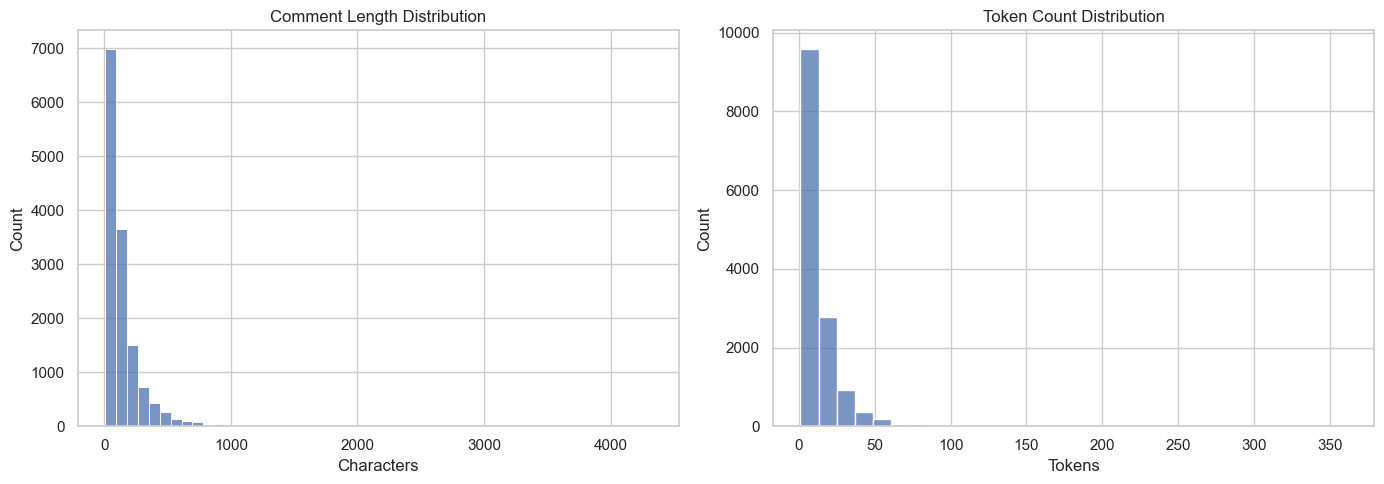

In [33]:
df["comment_length"] = df["text_clean_basic"].str.len()
df["token_count"] = df[TOKEN_COL].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["comment_length"], bins=50, ax=axes[0])
axes[0].set_title("Comment Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(df["token_count"], bins=30, ax=axes[1])
axes[1].set_title("Token Count Distribution")
axes[1].set_xlabel("Tokens")

plt.tight_layout()
plt.show()

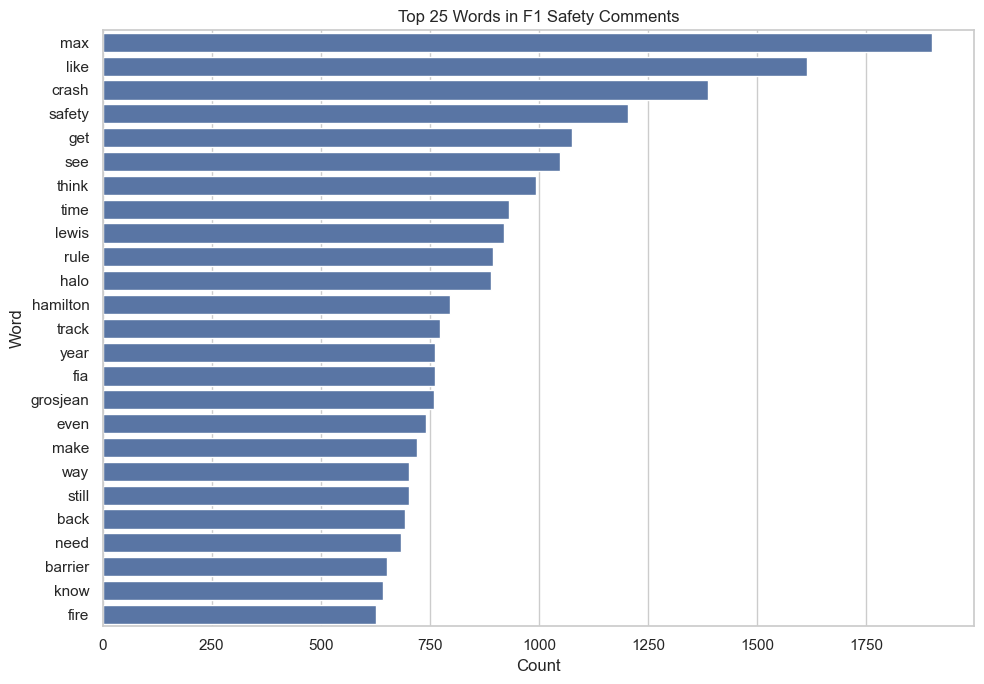

,word,count
0,max,1902
1,like,1614
2,crash,1387
3,safety,1205
4,get,1075
5,see,1048
6,think,993
7,time,932
8,lewis,921
9,rule,895


In [34]:
# Top words after preprocessing
all_tokens = [tok for toks in df[TOKEN_COL] for tok in toks]
top_words = pd.DataFrame(Counter(all_tokens).most_common(25), columns=["word", "count"])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_words, y="word", x="count")
plt.title("Top 25 Words in F1 Safety Comments")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

top_words.head(10)

## 11. TF-IDF and Bigram Analysis

This section applies TF-IDF and bigram analysis to identify the most important words and phrases appearing within YouTube discussions about Formula 1 safety.

These techniques help move beyond simple word frequency counts by highlighting terms that are both common and contextually meaningful within the dataset.

### TF-IDF Analysis

Term Frequency–Inverse Document Frequency (TF-IDF) is used to measure how important a word is within the comment corpus relative to the entire dataset.

Unlike raw frequency counts, TF-IDF reduces the influence of extremely common words and emphasises terms that are more distinctive or topic-specific. This makes it particularly useful for identifying important discussion themes and terminology related to Formula 1 safety.

The `TfidfVectorizer` is configured with:
- `max_features=1000` to limit vocabulary size
- `min_df=3` to remove extremely rare terms
- `max_df=0.85` to filter overly common terms that provide little analytical value

The resulting TF-IDF scores are averaged across all comments to identify the most influential and distinctive terms within the dataset.

Visualising the top TF-IDF terms helps reveal:
- Core safety-related concepts
- Frequently discussed incidents
- Technical terminology
- Emotional or opinion-driven language
- Regulatory and FIA-related discussions

This provides an initial understanding of the dominant themes emerging from the public discourse surrounding Formula 1 safety.

### Bigram Analysis

While TF-IDF focuses on individual words, bigram analysis examines pairs of consecutive words that frequently appear together.

This is important because many meaningful concepts in Formula 1 discussions are expressed as multi-word phrases rather than isolated terms. Examples may include:
- `"halo saved"`
- `"safety car"`
- `"fia rules"`
- `"driver safety"`
- `"red flag"`

The notebook uses `CountVectorizer` with:
- `ngram_range=(2,2)` to extract only bigrams
- `min_df=3` to remove infrequent phrases
- `max_features=500` to maintain manageable vocabulary size

The extracted bigrams are then ranked by frequency and visualised using bar charts.

Bigram analysis helps identify:
- Recurring discussion themes
- Common narratives within the community
- Safety-related terminology
- Public concerns and reactions
- Frequently referenced incidents or regulations

Together, TF-IDF and bigram analysis provide an interpretable overview of the language patterns within the dataset and help establish a foundation for later stages such as topic modelling, sentiment analysis, and semantic interpretation.

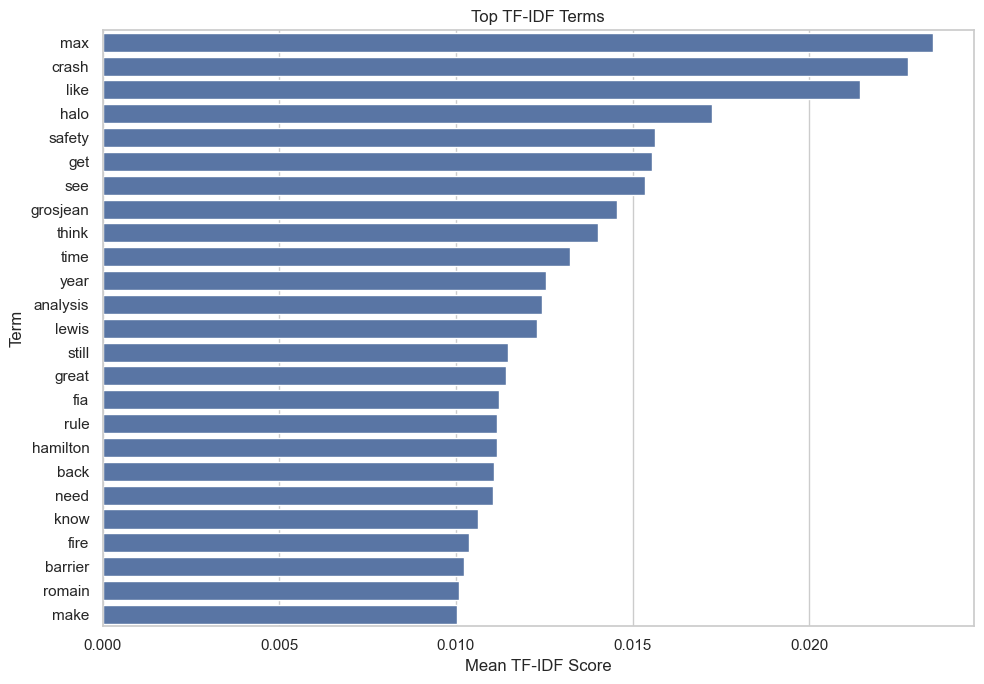

,term,score
566,max,0.023485
185,crash,0.022801
522,like,0.021441
397,halo,0.017250
753,safety,0.015645
364,get,0.015555
771,see,0.015354
387,grosjean,0.014569
887,think,0.014031
893,time,0.013228


In [35]:
tfidf = TfidfVectorizer(max_features=1000, min_df=3, max_df=0.85)
X_tfidf = tfidf.fit_transform(df[TEXT_COL])

tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_terms = tfidf.get_feature_names_out()

top_tfidf = pd.DataFrame({"term": tfidf_terms, "score": tfidf_scores})     .sort_values("score", ascending=False)     .head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_tfidf, y="term", x="score")
plt.title("Top TF-IDF Terms")
plt.xlabel("Mean TF-IDF Score")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

top_tfidf.head(10)

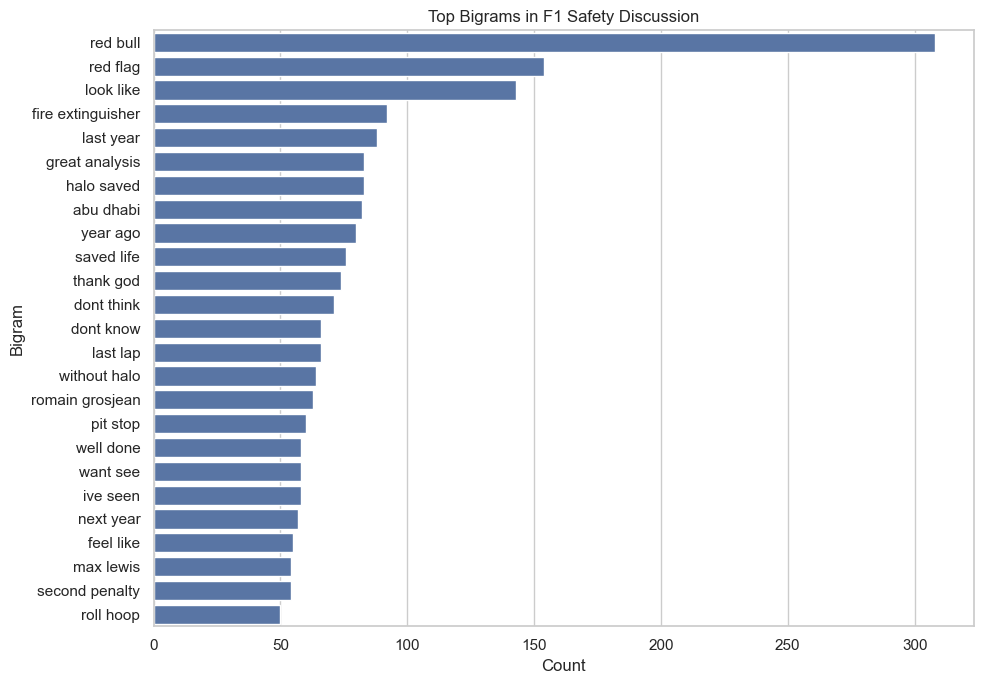

,bigram,count
351,red bull,308
352,red flag,154
262,look like,143
136,fire extinguisher,92
239,last year,88
176,great analysis,83
194,halo saved,83
1,abu dhabi,82
495,year ago,80
389,saved life,76


In [36]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=3, max_features=500)
X_bigrams = bigram_vectorizer.fit_transform(df[TEXT_COL])

bigram_counts = np.asarray(X_bigrams.sum(axis=0)).ravel()
bigram_terms = bigram_vectorizer.get_feature_names_out()

top_bigrams = pd.DataFrame({"bigram": bigram_terms, "count": bigram_counts})     .sort_values("count", ascending=False)     .head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_bigrams, y="bigram", x="count")
plt.title("Top Bigrams in F1 Safety Discussion")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

top_bigrams.head(10)

## 12. Sentiment Analysis: VADER and TextBlob

Sentiment analysis is used to examine the emotional tone and public opinion expressed within YouTube discussions about Formula 1 safety. Understanding sentiment is important because safety-related incidents often generate strong emotional reactions, including fear, anger, praise, criticism, and support for regulatory decisions.

This section applies two lexicon-based sentiment analysis techniques:
- **VADER (Valence Aware Dictionary and Sentiment Reasoner)**
- **TextBlob**

Using multiple sentiment methods allows the analysis to compare outputs and evaluate the consistency of sentiment classification across different approaches.

### VADER Sentiment Analysis

VADER is specifically designed for analysing social media and online conversational text. It performs well on informal language and can account for:
- Capitalisation
- Punctuation emphasis
- Slang and internet-style communication
- Emotional intensity

For each comment, VADER generates a compound sentiment score ranging from:
- `-1` (extremely negative)
- `+1` (extremely positive)

The notebook classifies comments into three categories using standard VADER thresholds:

- **Positive:** score ≥ 0.05  
- **Negative:** score ≤ -0.05  
- **Neutral:** otherwise  

VADER is particularly suitable for this project because YouTube comments often contain emotionally expressive language and informal writing patterns.

### TextBlob Sentiment Analysis

TextBlob is used as a secondary lexicon-based comparison model. It calculates sentiment polarity scores using a simpler rule-based approach.

Similar threshold values are applied to categorise comments into:
- Positive
- Neutral
- Negative

Although TextBlob is generally less specialised for social media text compared to VADER, it provides an additional reference point for evaluating sentiment consistency within the dataset.

### Sentiment Distribution Analysis

The resulting sentiment labels from both models are visualised using count plots to examine:
- Overall emotional trends
- Dominant public reactions
- Differences between sentiment methods

This helps identify whether Formula 1 safety discussions are primarily:
- Positive (supportive or appreciative)
- Negative (critical or emotional)
- Neutral (informational or balanced)

### Agreement Between Models

A heatmap is generated using a cross-tabulation between VADER and TextBlob sentiment labels.

This comparison helps evaluate:
- Areas of agreement between models
- Cases where sentiment interpretation differs
- The reliability and consistency of lexicon-based sentiment classification

High agreement between the two methods may indicate stable sentiment patterns, while disagreement may reveal:
- Ambiguous language
- Sarcasm
- Mixed emotional expression
- Context-dependent interpretations

Using multiple sentiment approaches strengthens the robustness of the analysis and provides deeper insight into how public opinion surrounding Formula 1 safety is expressed within online discussions.

In [37]:
sia = SentimentIntensityAnalyzer()

def vader_label(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        label = "positive"
    elif score <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return score, label


def textblob_label(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0.05:
        label = "positive"
    elif polarity < -0.05:
        label = "negative"
    else:
        label = "neutral"
    return polarity, label

vader_results = df["text_clean_basic"].apply(vader_label)
blob_results = df["text_clean_basic"].apply(textblob_label)

df["vader_score"] = vader_results.apply(lambda x: x[0])
df["vader_label"] = vader_results.apply(lambda x: x[1])
df["blob_score"] = blob_results.apply(lambda x: x[0])
df["blob_label"] = blob_results.apply(lambda x: x[1])

df[["text_clean_basic", "vader_score", "vader_label", "blob_score", "blob_label"]].head()

,text_clean_basic,vader_score,vader_label,blob_score,blob_label
0,Watch the much more realistic looking reconstruction of this accident ( which featured also in the Canal+ documentar...,-0.6016,negative,0.222222,positive
1,Every driver that lost his or her life in a race car saved Romain.,0.1280,positive,0.000000,neutral
2,That halo stopped us from seeing a flaming decapitation. Thank god for the progression of safety regulation in this ...,0.6705,positive,0.000000,neutral
3,Did the halo save Romain’s life? Short answer: yes Long answer: hell yes,0.4588,positive,-0.025000,neutral
4,The fact is that grosjean was actually against using the halo. Who knew it would end up saving his life,0.0000,neutral,0.000000,neutral


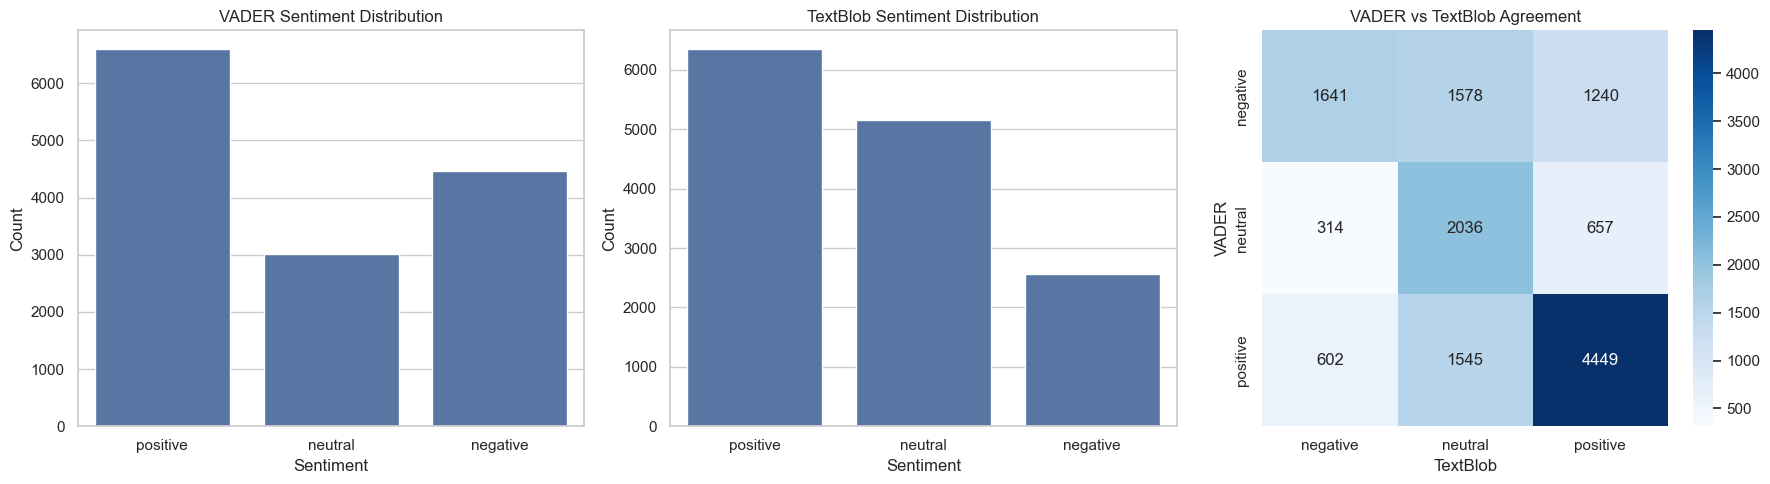

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="vader_label", order=["positive", "neutral", "negative"], ax=axes[0])
axes[0].set_title("VADER Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="blob_label", order=["positive", "neutral", "negative"], ax=axes[1])
axes[1].set_title("TextBlob Sentiment Distribution")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Count")

agreement = pd.crosstab(df["vader_label"], df["blob_label"])
sns.heatmap(agreement, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("VADER vs TextBlob Agreement")
axes[2].set_xlabel("TextBlob")
axes[2].set_ylabel("VADER")

plt.tight_layout()
plt.show()

## 13. Topic Modelling: LDA

Latent Dirichlet Allocation (LDA) is a generative probabilistic model that
treats each document as a mixture of topics and each topic as a distribution
over words.  It is one of the most widely used unsupervised techniques for
discovering thematic structure in a text corpus.

### Why LDA for F1 safety discussions?

YouTube comments are short, informal, and cover multiple overlapping themes
(driver safety, FIA regulations, specific incidents, emotional reactions).
LDA can separate these threads automatically without any labelled data.

### Configuration

- `n_components=8` — eight latent topics; a reasonable granularity for the
  breadth of F1 safety discourse.  Tune with perplexity / coherence if needed.
- `max_iter=20`, `learning_method='online'` — efficient for medium corpora.
- Input: lemmatised text (`text_C`) vectorised with `CountVectorizer`
  (raw counts are required by LDA; TF-IDF can suppress informative high-freq terms).

### Outputs

1. Top-10 words per topic — the primary qualitative signal for labelling.
2. A heatmap of the topic–word weight matrix for the top 30 terms.
3. Dominant topic assigned to every comment, enabling per-topic sentiment
   comparison in later sections.
4. A bar chart of how comments are distributed across topics.

Perplexity: 1289.4

── LDA Topics ──
  Topic 1: fire, point, track, first, give, get, corner, second, need, like
  Topic 2: great, analysis, see, best, safety, sport, well, thank, wrong, mean
  Topic 3: safety, going, fia, say, fan, season, start, ferrari, come, team
  Topic 4: crash, grosjean, got, year, romain, people, still, like, wheel, glad
  Topic 5: max, lewis, rule, hamilton, line, penalty, verstappen, back, win, bottas
  Topic 6: red, behind, bull, palmer, never, position, stroll, fair, flag, decision
  Topic 7: barrier, halo, lap, right, mercedes, driving, away, tyre, tire, saved
  Topic 8: like, think, dont, know, make, even, get, front, look, end


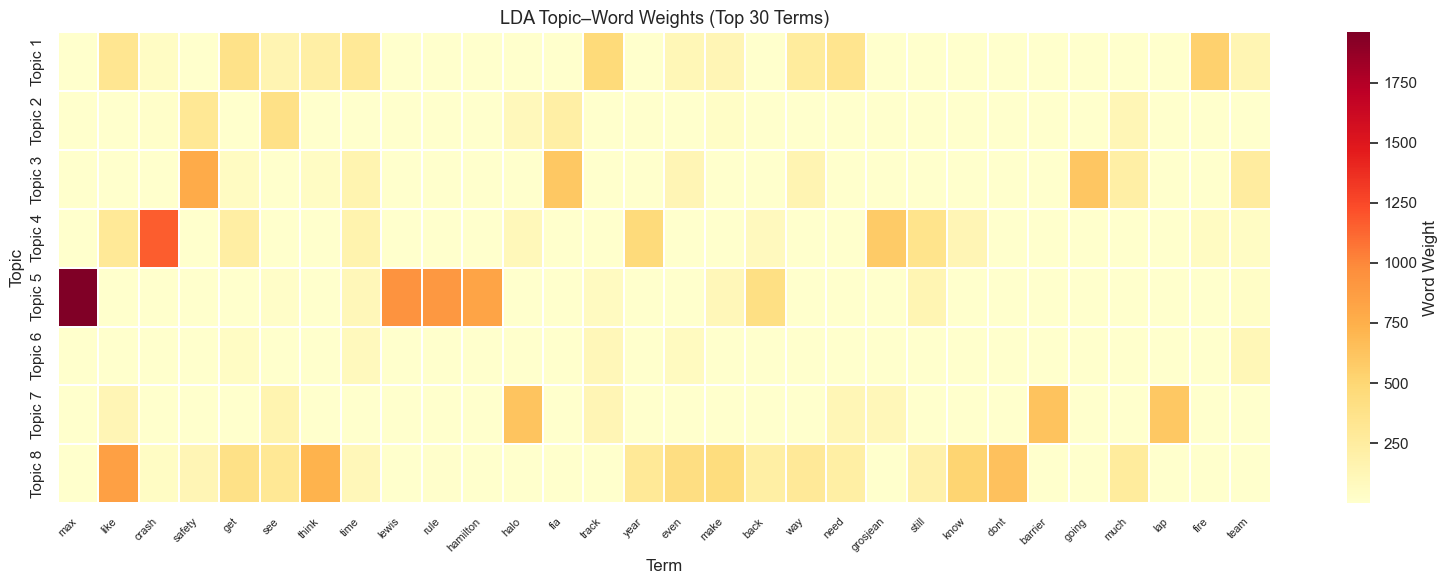

/var/folders/ym/kb42x5912gq0wfg8zh_4bk1r0000gn/T/ipykernel_69202/4051363965.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='tab10')


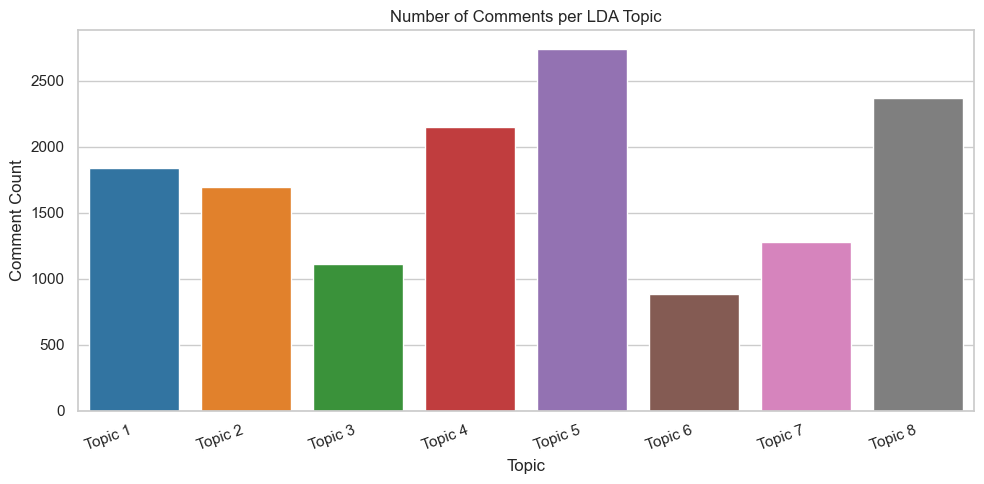

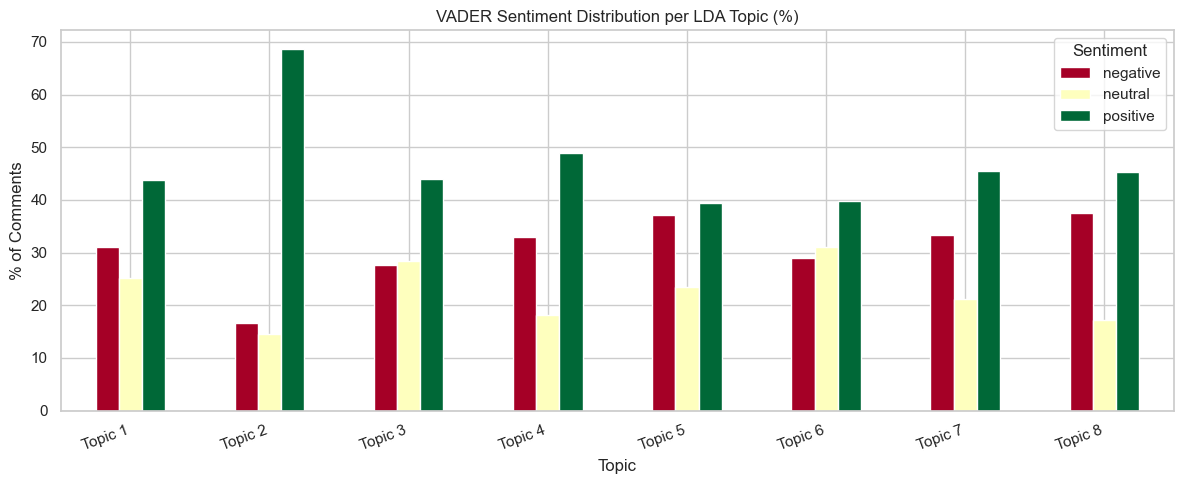

vader_label,negative,neutral,positive
lda_topic_label,,,
Topic 1,30.978261,25.163043,43.858696
Topic 2,16.656822,14.589486,68.753692
Topic 3,27.657658,28.378378,43.963964
Topic 4,32.960894,18.156425,48.882682
Topic 5,37.185563,23.405031,39.409406
Topic 6,29.039548,31.073446,39.887006
Topic 7,33.307210,21.159875,45.532915
Topic 8,37.600338,17.110266,45.289396


In [39]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Hyperparameters ──────────────────────────────────────────────────────
N_TOPICS_LDA  = 8
N_TOP_WORDS   = 10
MAX_FEATURES  = 2000

# ── 1. Vectorise (raw counts for LDA) ────────────────────────────────────
lda_vectorizer = CountVectorizer(
    max_features = MAX_FEATURES,
    min_df       = 3,
    max_df       = 0.90,
)
X_lda = lda_vectorizer.fit_transform(df[TEXT_COL])
lda_vocab = lda_vectorizer.get_feature_names_out()

# ── 2. Fit LDA ───────────────────────────────────────────────────────────
lda_model = LatentDirichletAllocation(
    n_components      = N_TOPICS_LDA,
    max_iter          = 20,
    learning_method   = 'online',
    random_state      = 42,
    n_jobs            = -1,
)
lda_doc_topics = lda_model.fit_transform(X_lda)   # shape: (n_docs, N_TOPICS_LDA)

print(f"Perplexity: {lda_model.perplexity(X_lda):.1f}")

# ── 3. Print top words per topic ─────────────────────────────────────────
print("\n── LDA Topics ──")
lda_topic_labels = []
for t_idx, topic_vec in enumerate(lda_model.components_):
    top_words = [lda_vocab[i] for i in topic_vec.argsort()[:-N_TOP_WORDS-1:-1]]
    label = f"Topic {t_idx+1}"
    lda_topic_labels.append(label)
    print(f"  {label}: {', '.join(top_words)}")

# ── 4. Assign dominant topic to each comment ─────────────────────────────
df["lda_topic"]       = lda_doc_topics.argmax(axis=1)
df["lda_topic_label"] = df["lda_topic"].apply(lambda i: lda_topic_labels[i])

# ── 5. Topic–word heatmap (top-30 terms) ─────────────────────────────────
top30_idx = lda_model.components_.sum(axis=0).argsort()[:-31:-1]
heatmap_data = pd.DataFrame(
    lda_model.components_[:, top30_idx],
    index   = lda_topic_labels,
    columns = lda_vocab[top30_idx],
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    cmap      = 'YlOrRd',
    linewidths= 0.3,
    annot     = False,
    cbar_kws  = {'label': 'Word Weight'},
)
plt.title("LDA Topic–Word Weights (Top 30 Terms)", fontsize=13)
plt.xlabel("Term")
plt.ylabel("Topic")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# ── 6. Topic distribution bar chart ──────────────────────────────────────
topic_counts = df["lda_topic_label"].value_counts().reindex(lda_topic_labels)

plt.figure(figsize=(10, 5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='tab10')
plt.title("Number of Comments per LDA Topic")
plt.xlabel("Topic")
plt.ylabel("Comment Count")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# ── 7. Per-topic sentiment breakdown ─────────────────────────────────────
topic_sentiment = (
    df.groupby(["lda_topic_label", "vader_label"])
    .size()
    .unstack(fill_value=0)
)
topic_sentiment_pct = topic_sentiment.div(topic_sentiment.sum(axis=1), axis=0) * 100

topic_sentiment_pct.plot(kind='bar', figsize=(12, 5), colormap='RdYlGn')
plt.title("VADER Sentiment Distribution per LDA Topic (%)")
plt.xlabel("Topic")
plt.ylabel("% of Comments")
plt.xticks(rotation=20, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

topic_sentiment_pct


## 14. Topic Modelling: LSA

Latent Semantic Analysis (LSA) applies Singular Value Decomposition (SVD) to a
TF-IDF matrix to uncover latent semantic dimensions shared across documents.
Unlike LDA, LSA does not impose a probabilistic generative model — it instead
finds orthogonal directions of maximum variance in the term-document space.

### LDA vs LSA — key differences

| | LDA | LSA |
|---|---|---|
| Model | Probabilistic generative | Linear algebraic (SVD) |
| Topic representation | Dirichlet distribution | Continuous latent dimensions |
| Handles polysemy | Partially | Better (via co-occurrence) |
| Interpretability | High (word probabilities) | Moderate (signed weights) |

Running both methods allows comparison of topic coherence and helps validate
whether the same thematic clusters emerge independently.

### Configuration

- `n_components=8` — same as LDA for direct comparability.
- Input: TF-IDF matrix (already built in Section 11; rebuilt here for clarity).
- `TruncatedSVD` is used (memory-efficient sparse SVD).

### Outputs

1. Top positive-weight terms per LSA component (interpretable as topics).
2. Explained-variance bar chart showing how much each component captures.
3. 2-D scatter of comments projected onto the two strongest LSA dimensions,
   coloured by VADER sentiment.
4. A side-by-side comparison table of LDA vs LSA top terms.

── LSA Components ──
  Component 1: max, crash, like, halo, safety, see, get, lewis, think, grosjean
  Component 2: halo, crash, grosjean, life, saved, romain, fire, barrier, thank, glad
  Component 3: analysis, great, palmer, jolyon, thanks, thank, excellent, best, always, love
  Component 4: crash, grosjean, worst, romain, year, see, bahrain, seen, watching, stroll
  Component 5: max, crash, halo, lewis, analysis, saved, great, life, george, palmer
  Component 6: like, look, crash, halo, see, sound, palmer, feel, seems, jolyon
  Component 7: grosjean, max, fire, like, romain, lewis, barrier, look, guy, see
  Component 8: palmer, fire, time, jolyon, back, still, ferrari, get, alonso, love


/var/folders/ym/kb42x5912gq0wfg8zh_4bk1r0000gn/T/ipykernel_69202/105063540.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lsa_topic_labels, y=explained, palette='Blues_d')


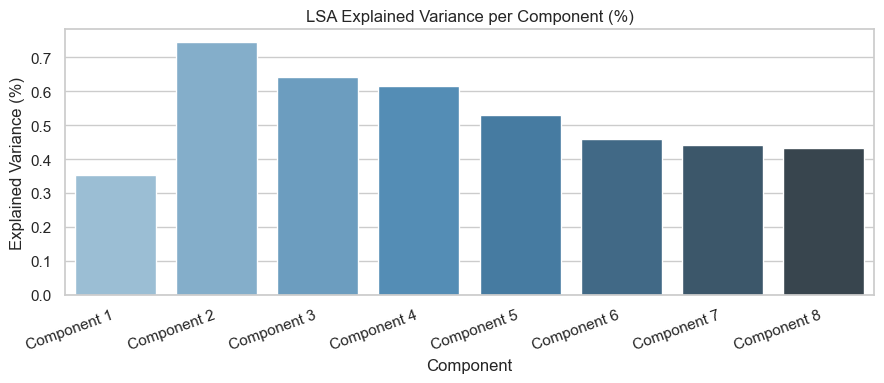

Total variance explained by 8 components: 4.2%


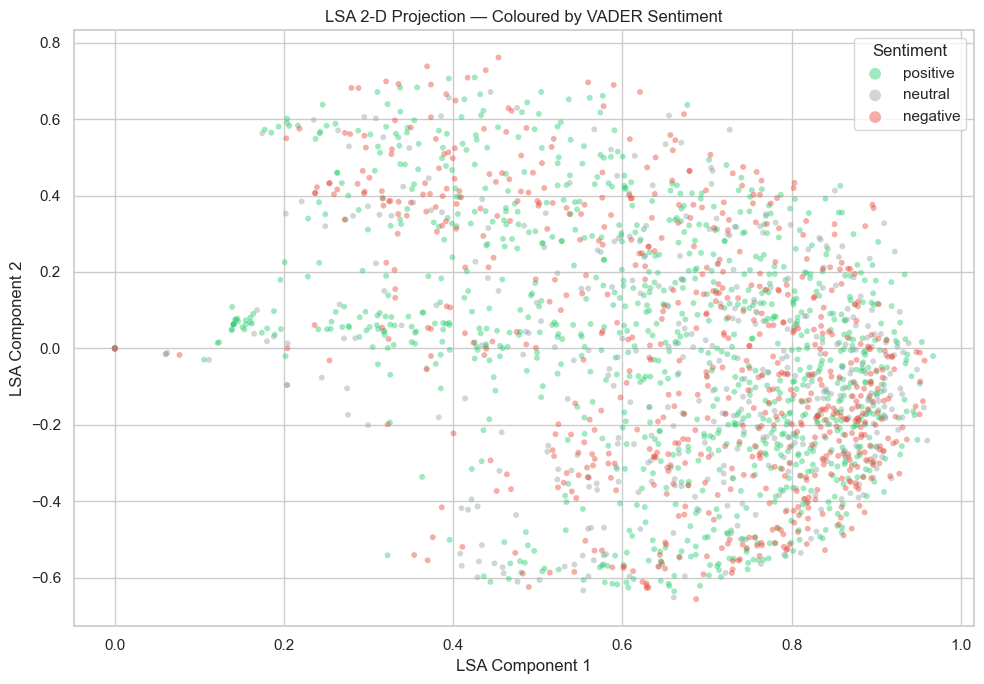


── LDA vs LSA Top Terms ──


,LDA top words,LSA top words
Topic #,,
1,"fire, point, track, first, give, get, corner, second, need, like","max, crash, like, halo, safety, see, get, lewis, think, grosjean"
2,"great, analysis, see, best, safety, sport, well, thank, wrong, mean","halo, crash, grosjean, life, saved, romain, fire, barrier, thank, glad"
3,"safety, going, fia, say, fan, season, start, ferrari, come, team","analysis, great, palmer, jolyon, thanks, thank, excellent, best, always, love"
4,"crash, grosjean, got, year, romain, people, still, like, wheel, glad","crash, grosjean, worst, romain, year, see, bahrain, seen, watching, stroll"
5,"max, lewis, rule, hamilton, line, penalty, verstappen, back, win, bottas","max, crash, halo, lewis, analysis, saved, great, life, george, palmer"
6,"red, behind, bull, palmer, never, position, stroll, fair, flag, decision","like, look, crash, halo, see, sound, palmer, feel, seems, jolyon"
7,"barrier, halo, lap, right, mercedes, driving, away, tyre, tire, saved","grosjean, max, fire, like, romain, lewis, barrier, look, guy, see"
8,"like, think, dont, know, make, even, get, front, look, end","palmer, fire, time, jolyon, back, still, ferrari, get, alonso, love"


In [40]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Hyperparameters ──────────────────────────────────────────────────────
N_TOPICS_LSA = 8

# ── 1. TF-IDF matrix for LSA ─────────────────────────────────────────────
lsa_tfidf = TfidfVectorizer(
    max_features = 2000,
    min_df       = 3,
    max_df       = 0.90,
)
X_lsa_raw = lsa_tfidf.fit_transform(df[TEXT_COL])
lsa_vocab  = lsa_tfidf.get_feature_names_out()

# ── 2. SVD + L2 normalisation (standard LSA pipeline) ────────────────────
svd_model   = TruncatedSVD(n_components=N_TOPICS_LSA, random_state=42)
normalizer  = Normalizer(copy=False)
lsa_pipeline = make_pipeline(svd_model, normalizer)
X_lsa = lsa_pipeline.fit_transform(X_lsa_raw)   # shape: (n_docs, N_TOPICS_LSA)

# ── 3. Print top terms per component ─────────────────────────────────────
print("── LSA Components ──")
lsa_topic_labels = []
lsa_top_terms    = []
for c_idx, comp in enumerate(svd_model.components_):
    top_words = [lsa_vocab[i] for i in comp.argsort()[:-N_TOP_WORDS-1:-1]]
    label = f"Component {c_idx+1}"
    lsa_topic_labels.append(label)
    lsa_top_terms.append(top_words)
    print(f"  {label}: {', '.join(top_words)}")

# ── 4. Assign dominant LSA component ─────────────────────────────────────
df["lsa_topic"]       = X_lsa.argmax(axis=1)
df["lsa_topic_label"] = df["lsa_topic"].apply(lambda i: lsa_topic_labels[i])

# ── 5. Explained-variance bar chart ──────────────────────────────────────
explained = svd_model.explained_variance_ratio_ * 100

plt.figure(figsize=(9, 4))
sns.barplot(x=lsa_topic_labels, y=explained, palette='Blues_d')
plt.title("LSA Explained Variance per Component (%)")
plt.xlabel("Component")
plt.ylabel("Explained Variance (%)")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(f"Total variance explained by {N_TOPICS_LSA} components: {explained.sum():.1f}%")

# ── 6. 2-D scatter coloured by VADER sentiment ────────────────────────────
sample_n  = min(2000, len(df))
samp_idx  = df.sample(sample_n, random_state=42).index
samp_proj = X_lsa[samp_idx]
samp_sent = df.loc[samp_idx, "vader_label"]

palette = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

plt.figure(figsize=(10, 7))
for sent, colour in palette.items():
    mask = samp_sent == sent
    plt.scatter(
        samp_proj[mask, 0], samp_proj[mask, 1],
        c=colour, label=sent, alpha=0.45, s=18, edgecolors='none'
    )
plt.title("LSA 2-D Projection — Coloured by VADER Sentiment")
plt.xlabel("LSA Component 1")
plt.ylabel("LSA Component 2")
plt.legend(title='Sentiment', markerscale=2)
plt.tight_layout()
plt.show()

# ── 7. LDA vs LSA top-terms comparison table ─────────────────────────────
lda_top_terms = [
    [lda_vocab[i] for i in row.argsort()[:-N_TOP_WORDS-1:-1]]
    for row in lda_model.components_
]

rows = []
for t in range(N_TOPICS_LDA):
    rows.append({
        "Topic #":       t + 1,
        "LDA top words": ", ".join(lda_top_terms[t]),
        "LSA top words": ", ".join(lsa_top_terms[t]),
    })

comparison_df = pd.DataFrame(rows).set_index("Topic #")
print("\n── LDA vs LSA Top Terms ──")
comparison_df


## 15. BERT / Sentence Embedding Analysis Optional Advanced Section

This section uses sentence embeddings to group semantically similar comments. It helps move beyond exact word matching and can strengthen the advanced analysis section.

If your machine is slow, sample the comments.

In [41]:
if HAS_SENTENCE_TRANSFORMERS:
    sample_size = min(1000, len(df))
    bert_sample = df.sample(sample_size, random_state=42).copy()

    model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = model.encode(bert_sample["text_clean_basic"].tolist(), show_progress_bar=True)

    print("Embedding shape:", embeddings.shape)
else:
    print("sentence-transformers is not installed. Skip this section or install it first.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (1000, 384)


In [42]:
# Optional: inspect semantic similarity between selected safety terms/comments
if HAS_SENTENCE_TRANSFORMERS:
    query_sentences = [
        "The halo saved the driver's life",
        "FIA safety rules are too strict",
        "Formula 1 is still very dangerous",
        "Modern safety technology has improved racing"
    ]
    query_embeddings = model.encode(query_sentences)
    sims = cosine_similarity(query_embeddings, embeddings)

    for i, q in enumerate(query_sentences):
        print("Query:", q)
        top_idx = sims[i].argsort()[-3:][::-1]
        for idx in top_idx:
            print("-", bert_sample.iloc[idx]["text_clean_basic"][:250])

Query: The halo saved the driver's life
- That halo, it saves lives. It bloody does save lives and this horrific crash has proved it. Thank you to those who brought up the halo to F1.
- Whoever came up with the halo saved a life here
- The Halo and the whole cockpit construction saved him. Still the Halo needs to be Replaced by the Aeroscreen. So drivers will be safe from parts flying around.
Query: FIA safety rules are too strict
- The FIA have admitted that they didn’t “fully” follow their own rules
- This was actually a huge triumph! Not only did established safety protocols work (and the driver walked away from a life threatening incident!) but the FIA is *still* trying to improve safety as a result. Great job to all
- Thank you FIA for improving safety.
Query: Formula 1 is still very dangerous
- Its glad R grosjen it’s still alive Remember when formula 1 change the safety rule after many drivers dead they make move to protect them is so sad to see dead in motorsports
- F1 Safety o

## 16. Network Construction: Word Co-occurrence Network

For A2, network analysis is essential. This section builds a word co-occurrence network where:

- nodes are important words
- edges connect words that appear in the same comment
- edge weight is the number of co-occurrences

This network shows which safety ideas are connected in public discussion.

In [43]:
def build_cooccurrence_network(token_lists, min_word_freq=20, window=None):
    word_counts = Counter(tok for toks in token_lists for tok in toks)
    vocab = {word for word, count in word_counts.items() if count >= min_word_freq}

    edge_counts = Counter()
    for toks in token_lists:
        toks = [t for t in toks if t in vocab]
        unique_tokens = list(dict.fromkeys(toks))

        if window is None:
            pairs_source = unique_tokens
            for i in range(len(pairs_source)):
                for j in range(i + 1, len(pairs_source)):
                    edge = tuple(sorted((pairs_source[i], pairs_source[j])))
                    edge_counts[edge] += 1
        else:
            for i in range(len(toks)):
                for j in range(i + 1, min(i + window, len(toks))):
                    if toks[i] != toks[j]:
                        edge = tuple(sorted((toks[i], toks[j])))
                        edge_counts[edge] += 1

    G = nx.Graph()
    for word, count in word_counts.items():
        if word in vocab:
            G.add_node(word, frequency=count)

    for (w1, w2), weight in edge_counts.items():
        if weight >= 3:
            G.add_edge(w1, w2, weight=weight)

    return G

G = build_cooccurrence_network(df[TOKEN_COL], min_word_freq=20)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1469
Edges: 127144


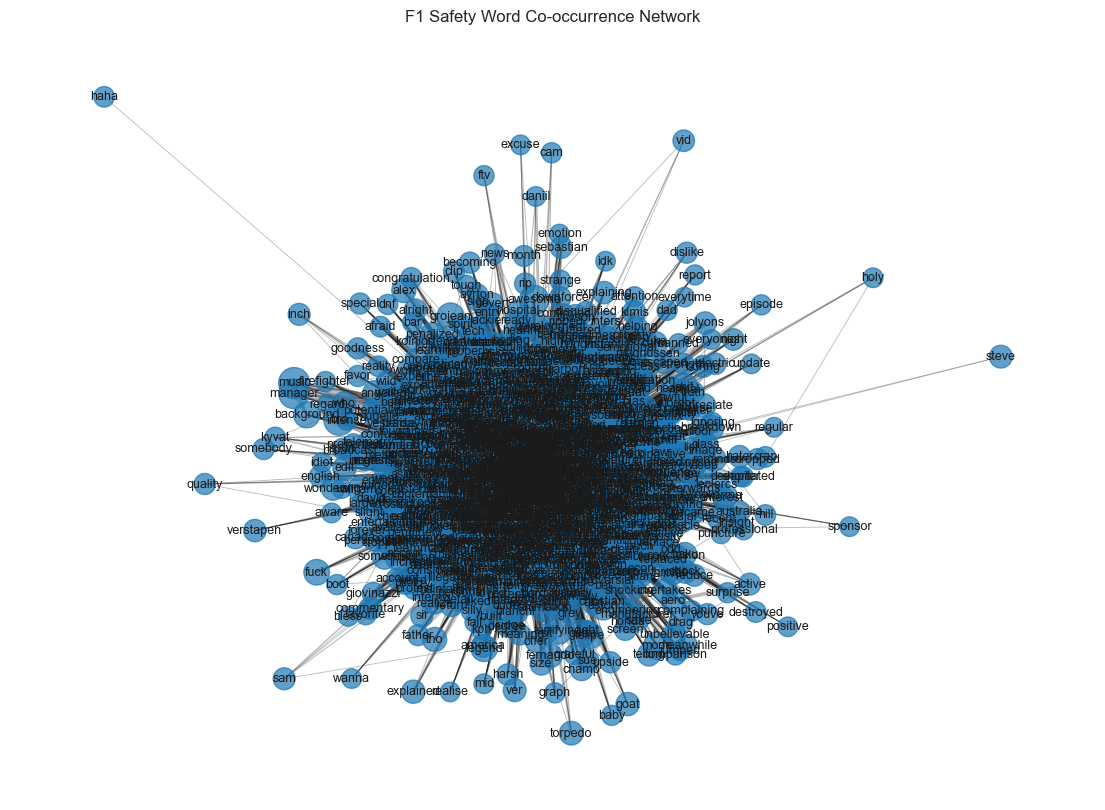

In [44]:
# Basic network visualisation
plt.figure(figsize=(14, 10))

# Use largest connected component for a cleaner visual
if G.number_of_nodes() > 0:
    largest_cc = max(nx.connected_components(G), key=len)
    G_vis = G.subgraph(largest_cc).copy()

    pos = nx.spring_layout(G_vis, k=0.5, seed=42)
    node_sizes = [G_vis.nodes[n]["frequency"] * 10 for n in G_vis.nodes]
    edge_widths = [G_vis[u][v]["weight"] * 0.2 for u, v in G_vis.edges]

    nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, alpha=0.7)
    nx.draw_networkx_edges(G_vis, pos, width=edge_widths, alpha=0.3)
    nx.draw_networkx_labels(G_vis, pos, font_size=9)
    plt.title("F1 Safety Word Co-occurrence Network")
    plt.axis("off")
    plt.show()
else:
    print("Network is empty. Lower min_word_freq if needed.")